In [1]:
!pip install nbformat

In [ ]:
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)  #batch gd
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)   #stochastic gd

In [13]:
import pandas as pd
import seaborn as sns

In [18]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load tips dataset — NO processing needed!
df = sns.load_dataset('tips')
print(df.shape)      # (244, 7)
print(df.head())

#    total_bill  tip   sex   smoker  day   time  size
#       16.99    1.01  Female  No    Sun  Dinner   2
#       10.34    1.66  Male    No    Sun  Dinner   3

(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [20]:
# Use only 2 columns — ZERO processing!
# Predict TIP from TOTAL_BILL only

X = df[['total_bill']].values   # input
y = df[['tip']].values          # output

print("X shape:", X.shape)   # (244, 1)
print("y shape:", y.shape)   # (244, 1)

X shape: (244, 1)
y shape: (244, 1)


In [21]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🧠 WHAT IS GRADIENT DESCENT?

Gradient Descent = How the model LEARNS by reducing loss

Imagine you are on a hill 🏔️
You want to reach the BOTTOM (lowest loss)
Each step you take = one weight update

3 ways to take steps:
─────────────────────────────────────────────
1. BATCH GD      → look at ALL data then step
2. STOCHASTIC GD → look at 1 sample then step
3. MINI BATCH GD → look at small group then step

In [22]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🧠 WHAT IS GRADIENT DESCENT?
```
Gradient Descent = How the model LEARNS by reducing loss

Imagine you are on a hill 🏔️
You want to reach the BOTTOM (lowest loss)
Each step you take = one weight update

3 ways to take steps:
─────────────────────────────────────────────
1. BATCH GD      → look at ALL data then step
2. STOCHASTIC GD → look at 1 sample then step
3. MINI BATCH GD → look at small group then step

In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

def build_model():
    model = Sequential([
        Dense(4, activation='relu', input_shape=(1,)),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='sgd',
                  loss='mse',
                  metrics=['mae'])
    return model

In [24]:
model_batch = build_model()

history_batch = model_batch.fit(
    X_scaled, y,
    epochs     = 100,
    batch_size = len(X_scaled),   # ← ALL data at once (244)
    validation_split = 0.2,
    verbose    = 1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - loss: 10.2862 - mae: 2.9893 - val_loss: 8.6016 - val_mae: 2.6370
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 9.6548 - mae: 2.8898 - val_loss: 8.0304 - val_mae: 2.5368
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 9.0646 - mae: 2.7933 - val_loss: 7.4991 - val_mae: 2.4395
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 8.5118 - mae: 2.6993 - val_loss: 7.0049 - val_mae: 2.3469
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 7.9945 - mae: 2.6078 - val_loss: 6.5456 - val_mae: 2.2616
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 7.5110 - mae: 2.5188 - val_loss: 6.1191 - val_mae: 2.1786
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 7.0590 - mae: 2.4322 - val_loss: 5.7240 - val_mae: 2.0980
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 6.6373 - mae: 2.3502 - val_loss: 5.3563 - val_mae: 2.0193
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 6.2444 - mae: 2.2704 - v

In [25]:
model_sgd = build_model()

history_sgd = model_sgd.fit(
    X_scaled, y,
    epochs     = 100,
    batch_size = 1,     # ← 1 sample at a time
    validation_split = 0.2,
    verbose    = 1
)

Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2781 - mae: 1.7338 - val_loss: 1.8717 - val_mae: 1.0869
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3649 - mae: 0.8721 - val_loss: 1.4194 - val_mae: 0.9310
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3760 - mae: 0.9003 - val_loss: 1.3289 - val_mae: 0.8519
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0338 - mae: 0.7579 - val_loss: 1.8105 - val_mae: 1.0163
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4264 - mae: 0.9212 - val_loss: 1.4355 - val_mae: 0.9135
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9558 - mae: 0.7325 - val_loss: 1.4131 - val_mae: 0.9085
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0769 - mae: 0.7773 - val_loss: 1.3521 - val_mae: 0.8698
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0189 - mae: 0.7404 - val_loss: 1.7467 - val_mae: 0.9932
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [26]:
model_mini = build_model()

history_mini = model_mini.fit(
    X_scaled, y,
    epochs     = 100,
    batch_size = 32,    # ← small group of 32
    validation_split = 0.2,
    verbose    = 1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 7.0156 - mae: 2.4284 - val_loss: 4.1489 - val_mae: 1.7616
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.5931 - mae: 1.9114 - val_loss: 2.7986 - val_mae: 1.3908
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.0438 - mae: 1.5246 - val_loss: 2.0376 - val_mae: 1.1734
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9387 - mae: 1.1570 - val_loss: 1.7421 - val_mae: 1.0622
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4063 - mae: 0.9269 - val_loss: 1.5202 - val_mae: 0.9609
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3142 - mae: 0.8664 - val_loss: 1.4051 - val_mae: 0.9097
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1403 - mae: 0.7663 - val_loss: 1.3527 - val_mae: 0.8683
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9674 - mae: 0.6840 - val_loss: 1.3740 - val_mae: 0.8725
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1867 - mae: 

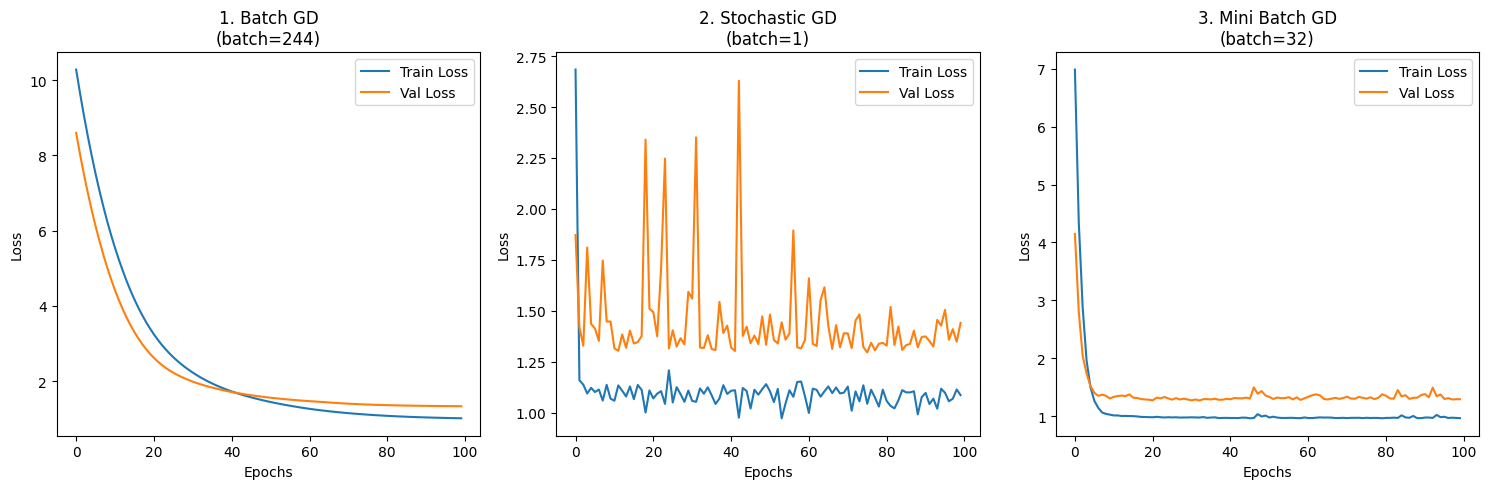

In [27]:
plt.figure(figsize=(15, 5))

# ── Plot 1: Batch GD ──────────────────────────────────────
plt.subplot(1, 3, 1)
plt.plot(history_batch.history['loss'],     label='Train Loss')
plt.plot(history_batch.history['val_loss'], label='Val Loss')
plt.title('1. Batch GD\n(batch=244)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# ── Plot 2: Stochastic GD ─────────────────────────────────
plt.subplot(1, 3, 2)
plt.plot(history_sgd.history['loss'],     label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Val Loss')
plt.title('2. Stochastic GD\n(batch=1)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# ── Plot 3: Mini Batch GD ─────────────────────────────────
plt.subplot(1, 3, 3)
plt.plot(history_mini.history['loss'],     label='Train Loss')
plt.plot(history_mini.history['val_loss'], label='Val Loss')
plt.title('3. Mini Batch GD\n(batch=32)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()